In [12]:
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

## Configuration

In [13]:
RESULTS_DIR = 'MDC_results'
PLOTS_DIR   = 'plots'

FEATURE_SETS = ['reference', 'demographic_node_text_node_audio_task']#, 'full',]  # demographic_linguistic_acoustic_task

# Target ordering (left -> right across panels)
TARGETS = ['language']#, 'memory', 'executive_function', 'speed']
TARGET_LABELS = {
    'language':           'Language',
    'memory':             'Memory',
    'executive_function': 'Executive Function',
    'speed':              'Speed',
}
FEATURE_SET_LABELS = {
    'full': 'Fine-tuning & hand-crafted',
    'demographic_node_text_node_audio_task': 'Fine-tuning (Additional)',
    'reference': 'Features (Study 4)',
}

# Cohorts (one figure per cohort)
COHORTS = ['A', 'B']

# Task ordering within each panel (cognition is appended automatically as the last column)
# Order matches the original screenshot: largest typical MDC on the left, smallest just before cognition.
TASKS = ['journaling', 'cookieTheft', 'picnicScene', 'avg_speech_prediction']
TASK_LABELS = {
    'journaling':            'Journaling',
    'cookieTheft':           'Cookie Theft',
    'picnicScene':           'Picnic Scene',
    'avg_speech_prediction': 'Avg. Speech Pred.',
}

COLORS = {
    'better':   '#1E8449',
    'overlap':  '#5D6D7E',
    'worse':    '#C0392B',
    'cog':      '#E67E22',
    'cog_dark': '#AF601A',
    'cog_band': '#F5CBA7',
    'icc':      '#16A085',   # teal, row 2 ICC line
    'r2':       '#8E44AD',   # purple, row 2 R² line
    'zero':     '#999999',   # subtle y=0 reference in row 2
}

os.makedirs(PLOTS_DIR, exist_ok=True)

## Load and parse the per-target CSVs

In [14]:
MDC_RE = re.compile(r'^\s*([0-9.]+)\s*\(\s*([0-9.]+)\s*-\s*([0-9.]+)\s*\)\s*$')

# R² CIs can be negative on either bound, e.g. '0.16 (-0.02-0.28)'. We allow leading sign on lo/hi.
SIGNED_CI_RE = re.compile(
    r'^\s*(-?[0-9.]+)\s*\(\s*(-?[0-9.]+)\s*-\s*(-?[0-9.]+)\s*\)\s*$'
)

SIG_RE = re.compile(
    r'^\s*'
    r'(-?[\d.]+(?:e[+-]?\d+)?)'        # bootstrap-difference CI low
    r'\s*-\s*'                          # separator
    r'(-?[\d.]+(?:e[+-]?\d+)?)'        # bootstrap-difference CI high
    r'\s*(\*?)\s*$'                    # optional asterisk marks significance
)

def parse_mdc(s):
    """Parse strings like '1.48 (1.29-1.67)' into (point, lo, hi).
    All three values must be non-negative."""
    m = MDC_RE.match(str(s))
    if m is None:
        raise ValueError(f'Cannot parse MDC string: {s!r}')
    return float(m.group(1)), float(m.group(2)), float(m.group(3))


def parse_signed_text_ci(s):
    """Parse strings like '0.16 (-0.02-0.28)' into (point, lo, hi). Used for R² CIs."""
    m = SIGNED_CI_RE.match(str(s))
    if m is None:
        raise ValueError(f'Cannot parse signed CI string: {s!r}')
    return float(m.group(1)), float(m.group(2)), float(m.group(3))


def parse_significance(s):
    """Parse strings like '2.4-6.8*' or '-0.28-0.59' or '0.67-1.5e+01*'.

    Returns (ci_low, ci_high, is_significant). The CI here is the bootstrap CI
    of (speech_mdc - cog_mdc); the asterisk indicates the CI excludes zero.
    """
    m = SIG_RE.match(str(s))
    if m is None:
        raise ValueError(f'Cannot parse significance string: {s!r}')
    return float(m.group(1)), float(m.group(2)), m.group(3) == '*'


def load_target_csv(target, feature_set, results_dir=RESULTS_DIR):
    if feature_set == 'reference':
        # reference = MDC paper publication (so features only)
        return pd.read_csv(f'/Users/jheitz/git/luha-prolific-study/analyses/kw21_MDC_paper/MDC_results/{target}.csv', index_col=0)
    return pd.read_csv(f'{results_dir}/{target}_{feature_set}.csv', index_col=0)


def build_long_table(targets=TARGETS, tasks=TASKS, cohorts=COHORTS, feature_sets=FEATURE_SETS,
                     results_dir=RESULTS_DIR):
    """Tidy table: one row per (target, cohort, task) with parsed MDCs and
    (when available) bootstrap-test significance vs cognitive MDC."""
    rows = []
    for target in targets:
        for feature_set in feature_sets:
            try:
                df = load_target_csv(target, feature_set, results_dir=results_dir)
            except FileNotFoundError:
                print(f'warning: no CSV for target {target!r}, skipping')
                continue
            for cohort in cohorts:
                if cohort not in df.columns:
                    continue
                col = df[cohort]
                # Cognitive MDC is the same for every task row; take it from the first available task
                cog_val, cog_lo, cog_hi = parse_mdc(
                    col[f'{tasks[0]}_mdc_cognitive_text']
                )
                # Cognitive ICC: prefer the per-task `_icc_cognitive_text` (with CI), fall back to ICC scalar
                cog_icc_key = f'{tasks[0]}_icc_cognitive_text'
                if cog_icc_key in col.index and pd.notna(col[cog_icc_key]):
                    cog_icc, cog_icc_lo, cog_icc_hi = parse_mdc(col[cog_icc_key])
                elif 'ICC' in col.index and pd.notna(col['ICC']):
                    cog_icc = float(col['ICC'])
                    cog_icc_lo = cog_icc_hi = np.nan
                else:
                    cog_icc = cog_icc_lo = cog_icc_hi = np.nan
                n = int(float(col['n'])) if 'n' in col.index else None
                for task in tasks:
                    key = f'{task}_mdc_speech_latent'
                    if key not in col.index:
                        continue
                    spe_val, spe_lo, spe_hi = parse_mdc(col[key])
                    # Optional per-task significance (bootstrap test of speech - cog)
                    sig_key = f'{task}_significance'
                    if sig_key in col.index and pd.notna(col[sig_key]):
                        sig_lo, sig_hi, sig = parse_significance(col[sig_key])
                    else:
                        sig_lo, sig_hi, sig = (np.nan, np.nan, None)
                    # Per-task ICC: prefer `{task}_icc_text` (CI), fall back to ICC_{task} scalar
                    icc_text_key = f'{task}_icc_text'
                    icc_scalar_key = f'ICC_{task}'
                    if icc_text_key in col.index and pd.notna(col[icc_text_key]):
                        icc, icc_lo, icc_hi = parse_mdc(col[icc_text_key])
                    elif icc_scalar_key in col.index and pd.notna(col[icc_scalar_key]):
                        icc = float(col[icc_scalar_key])
                        icc_lo = icc_hi = np.nan
                    else:
                        icc = icc_lo = icc_hi = np.nan
                    # Per-task R²: prefer `_regression_r2_text` (CI, may be negative), fall back to scalar
                    r2_text_key = f'{task}_regression_r2_text'
                    r2_scalar_key = f'{task}_regression_r2'
                    if r2_text_key in col.index and pd.notna(col[r2_text_key]):
                        r2, r2_lo, r2_hi = parse_signed_text_ci(col[r2_text_key])
                    elif r2_scalar_key in col.index and pd.notna(col[r2_scalar_key]):
                        r2 = float(col[r2_scalar_key])
                        r2_lo = r2_hi = np.nan
                    else:
                        r2 = r2_lo = r2_hi = np.nan
                    rows.append({
                        'target':     target,
                        'feature_set': feature_set,
                        'cohort':     cohort,
                        'task':       task,
                        'n':          n,
                        'mdc':        spe_val,
                        'mdc_lo':     spe_lo,
                        'mdc_hi':     spe_hi,
                        'cog_mdc':    cog_val,
                        'cog_lo':     cog_lo,
                        'cog_hi':     cog_hi,
                        'sig_lo':     sig_lo,
                        'sig_hi':     sig_hi,
                        'sig':        sig,
                        'icc':        icc,
                        'icc_lo':     icc_lo,
                        'icc_hi':     icc_hi,
                        'r2':         r2,
                        'r2_lo':      r2_lo,
                        'r2_hi':      r2_hi,
                        'cog_icc':    cog_icc,
                        'cog_icc_lo': cog_icc_lo,
                        'cog_icc_hi': cog_icc_hi,
                    })
    return pd.DataFrame(rows)


long_df = build_long_table()
long_df

,target,feature_set,cohort,task,n,mdc,mdc_lo,mdc_hi,cog_mdc,cog_lo,...,sig,icc,icc_lo,icc_hi,r2,r2_lo,r2_hi,cog_icc,cog_icc_lo,cog_icc_hi
0,language,reference,A,journaling,305,2.86,2.29,3.68,1.48,1.30,...,True,0.57,0.49,0.63,0.15,0.04,0.22,0.69,0.60,0.75
1,language,reference,A,cookieTheft,305,2.43,1.95,3.04,1.48,1.30,...,True,0.65,0.58,0.71,0.19,0.11,0.26,0.69,0.60,0.75
2,language,reference,A,picnicScene,305,1.88,1.52,2.32,1.48,1.30,...,False,0.76,0.70,0.80,0.23,0.14,0.29,0.69,0.60,0.75
3,language,reference,A,avg_speech_prediction,305,1.61,1.33,1.98,1.48,1.30,...,False,0.80,0.76,0.83,0.25,0.17,0.31,0.69,0.60,0.75
4,language,reference,B,journaling,70,2.03,1.32,3.60,1.39,1.04,...,False,0.74,0.56,0.85,0.22,0.02,0.35,0.71,0.58,0.80
5,language,reference,B,cookieTheft,70,1.66,1.13,2.37,1.39,1.04,...,False,0.76,0.60,0.85,0.30,0.12,0.42,0.71,0.58,0.80
6,language,reference,B,picnicScene,70,1.28,0.91,1.84,1.39,1.04,...,False,0.84,0.75,0.90,0.32,0.12,0.46,0.71,0.58,0.80
7,language,reference,B,avg_speech_prediction,70,1.07,0.73,1.52,1.39,1.04,...,False,0.89,0.82,0.93,0.32,0.16,0.44,0.71,0.58,0.80
8,language,demographic_node_text_node_audio_task,A,journaling,305,2.44,1.94,3.07,1.46,1.29,...,True,0.63,0.56,0.70,0.18,0.08,0.27,0.68,0.60,0.75
9,language,demographic_node_text_node_audio_task,A,cookieTheft,305,1.93,1.58,2.38,1.46,1.29,...,True,0.72,0.66,0.78,0.23,0.14,0.30,0.68,0.60,0.75


/var/folders/r9/m9sbl76n2l35rg8_r625jr1m0000gn/T/ipykernel_7096/4103112096.py:343: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.945])


saved: plots/wavlm_deberta_MDC_bars_cohortA.pdf


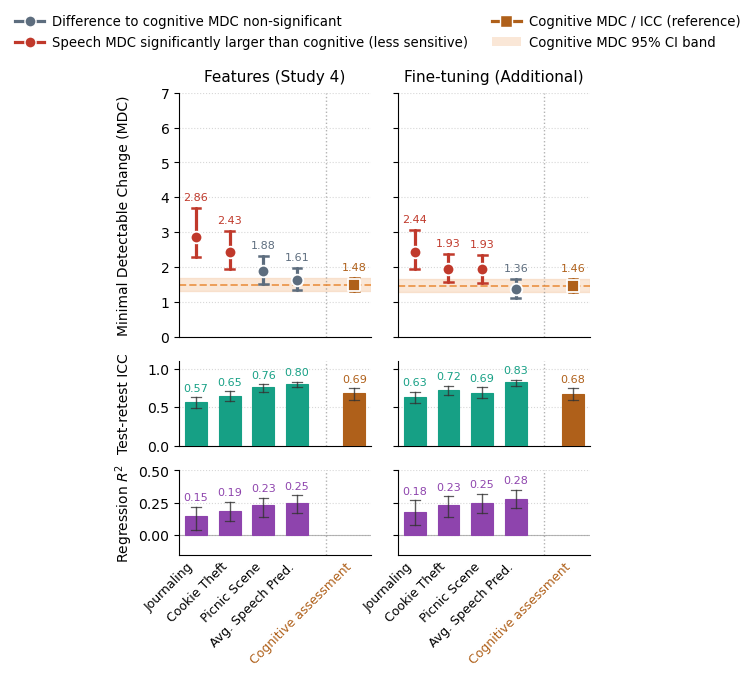

/var/folders/r9/m9sbl76n2l35rg8_r625jr1m0000gn/T/ipykernel_7096/4103112096.py:343: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.945])


saved: plots/wavlm_deberta_MDC_bars_cohortB.pdf


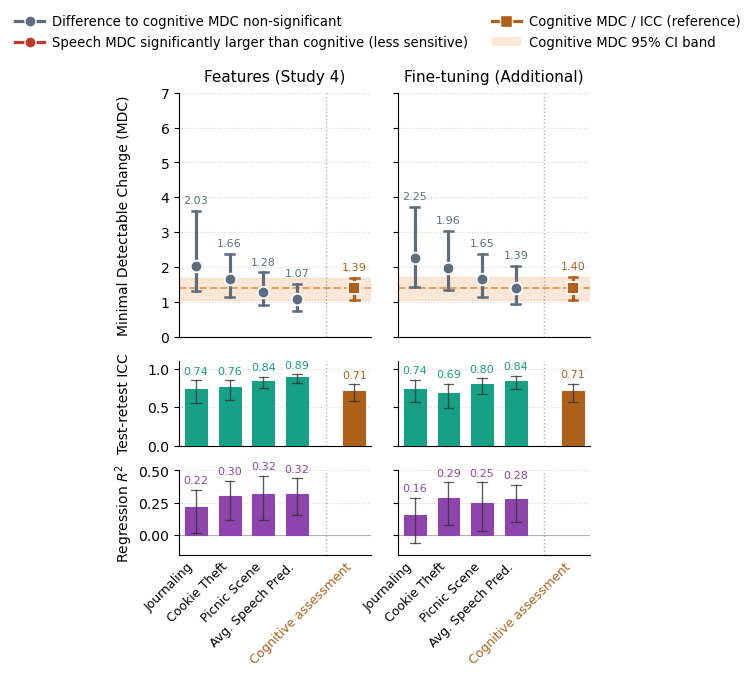

In [15]:

def classify_from_significance(sig_lo, sig_hi, sig):
    """Use bootstrap CI of (speech_mdc - cog_mdc). `sig` flags asterisk-significance."""
    if not sig:
        return 'overlap'
    if sig_lo > 0:
        return 'worse'
    if sig_hi < 0:
        return 'better'
    return 'overlap'

def classify_by_ci(speech_lo, speech_hi, cog_lo, cog_hi):
    """Conservative fallback when bootstrap-test significance is unavailable."""
    if speech_hi < cog_lo:
        return 'better'
    if speech_lo > cog_hi:
        return 'worse'
    return 'overlap'


def classify_row(row):
    """Bootstrap-test classification when present, CI-overlap fallback otherwise."""
    if row.get('sig') is not None and pd.notna(row.get('sig_lo')):
        return classify_from_significance(row['sig_lo'], row['sig_hi'], row['sig'])
    return classify_by_ci(row['mdc_lo'], row['mdc_hi'], row['cog_lo'], row['cog_hi'])



# x positions are shared by row 1 and row 2 to keep columns vertically aligned
_GAP = 0.7

def _x_positions(n_speech):
    x_speech = np.arange(n_speech)
    x_cog    = n_speech + _GAP
    return x_speech, x_cog



def _draw_bar(ax, x, height, *, width=0.65, color='#999', edge=None,
              ci_lo=None, ci_hi=None, annotate_value=True,
              annotate_fmt='{:.2f}', baseline=0.0):
    """Draw a single bar (rising from `baseline` to `height`) with optional CI whisker."""
    if not pd.notna(height):
        return
    bottom, top = (baseline, height) if height >= baseline else (height, baseline)
    ax.bar(x, top - bottom, bottom=bottom, width=width,
           color=color, edgecolor=edge or color, linewidth=0.8, zorder=3)
    if ci_lo is not None and ci_hi is not None and pd.notna(ci_lo) and pd.notna(ci_hi):
        ax.plot([x, x], [ci_lo, ci_hi], color='#333', linewidth=1.0,
                alpha=0.8, zorder=4)
        cap = width * 0.22
        ax.plot([x - cap, x + cap], [ci_lo, ci_lo],
                color='#333', linewidth=0.9, alpha=0.8, zorder=4)
        ax.plot([x - cap, x + cap], [ci_hi, ci_hi],
                color='#333', linewidth=0.9, alpha=0.8, zorder=4)
    if annotate_value:
        y_top = ci_hi if (ci_hi is not None and pd.notna(ci_hi) and ci_hi > height) else height
        ax.annotate(annotate_fmt.format(height), xy=(x, y_top), xytext=(0, 3),
                    textcoords='offset points',
                    fontsize=8, ha='center', va='bottom', color=color)


def make_panel(ax, df_panel, *, show_ylabel=True, title=None, annotate=True,
               show_xticklabels=True, cap_halfwidth=0.13, ylim=None):
    """Row-1 panel: MDC forest plot for one target."""
    speech_df = df_panel.set_index('task').loc[TASKS].reset_index()
    n_speech = len(speech_df)
    x_speech, x_cog = _x_positions(n_speech)

    cog_val = float(speech_df['cog_mdc'].iloc[0])
    cog_lo  = float(speech_df['cog_lo'].iloc[0])
    cog_hi  = float(speech_df['cog_hi'].iloc[0])

    ax.axhspan(cog_lo, cog_hi, color=COLORS['cog_band'], alpha=0.45, zorder=1)
    ax.axhline(cog_val, color=COLORS['cog'], linestyle='--',
               linewidth=1.4, alpha=0.7, zorder=2)

    sep_x = (x_speech[-1] + x_cog) / 2
    ax.axvline(sep_x, color='gray', linestyle=':',
               linewidth=1, alpha=0.6, zorder=1)

    for x, (_, row) in zip(x_speech, speech_df.iterrows()):
        color = COLORS[classify_row(row)]
        ax.plot([x, x], [row['mdc_lo'], row['mdc_hi']],
                color=color, linewidth=2.3,
                solid_capstyle='round', zorder=3)
        ax.plot([x - cap_halfwidth, x + cap_halfwidth],
                [row['mdc_lo'], row['mdc_lo']],
                color=color, linewidth=1.8, zorder=3)
        ax.plot([x - cap_halfwidth, x + cap_halfwidth],
                [row['mdc_hi'], row['mdc_hi']],
                color=color, linewidth=1.8, zorder=3)
        ax.scatter([x], [row['mdc']], s=70, color=color,
                   edgecolor='white', linewidth=1.3, zorder=4)
        if annotate:
            xy = (x, row['mdc_hi'])
            va = "bottom"
            ha = "center"
            bbox = None
            if ylim is not None and row['mdc_hi'] > ylim[1]:
                #xy = (x, row['mdc_hi']) if row['mdc_hi'] < ylim[1] else (x, ylim[1])
                #va = "bottom" if row['mdc_hi'] < ylim[1] else "top"
                xy = (x, row['mdc_hi']) if row['mdc_hi'] < ylim[1] else (x, row['mdc'])
                va = "bottom"
                bbox = dict(facecolor="white", alpha=0.8, edgecolor="none")
            ax.annotate(f"{row['mdc']:.2f}",
                        xy=xy, xytext=(0, 4),
                        textcoords='offset points',
                        fontsize=8, ha=ha, va=va, color=color,
                        bbox=bbox)

    ax.plot([x_cog, x_cog], [cog_lo, cog_hi],
            color=COLORS['cog_dark'], linewidth=2.3,
            solid_capstyle='round', zorder=3)
    ax.plot([x_cog - cap_halfwidth, x_cog + cap_halfwidth], [cog_lo, cog_lo],
            color=COLORS['cog_dark'], linewidth=1.8, zorder=3)
    ax.plot([x_cog - cap_halfwidth, x_cog + cap_halfwidth], [cog_hi, cog_hi],
            color=COLORS['cog_dark'], linewidth=1.8, zorder=3)
    ax.scatter([x_cog], [cog_val], s=70, color=COLORS['cog_dark'],
               marker='s', edgecolor='white', linewidth=1.3, zorder=4)
    if annotate:
        ax.annotate(f'{cog_val:.2f}',
                    xy=(x_cog, cog_hi), xytext=(0, 4),
                    textcoords='offset points',
                    fontsize=8, ha='center', va='bottom',
                    color=COLORS['cog_dark'])

    x_positions = list(x_speech) + [x_cog]
    ax.set_xticks(x_positions)
    if show_xticklabels:
        x_labels = [TASK_LABELS[t] for t in speech_df['task']] + ['Cognitive assessment']
        ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)
        ax.get_xticklabels()[-1].set_color(COLORS['cog_dark'])
    else:
        ax.tick_params(axis='x', labelbottom=False)

    ax.set_xlim(-0.5, x_cog + 0.5)
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    ax.set_axisbelow(True)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    ax.tick_params(axis='x', length=0)

    if show_ylabel:
        ax.set_ylabel('Minimal Detectable Change (MDC)')
    else:
        ax.tick_params(axis='y', labelleft=False)
    if title:
        ax.set_title(title, fontsize=11, pad=8)


def make_panel_icc_bars(ax, df_panel, *, show_ylabel=True, annotate=True,
                         show_xticklabels=True, ylim=(0.0, 1.0)):
    """ICC bars: one per speech task plus a cognition bar."""
    speech_df = df_panel.set_index('task').loc[TASKS].reset_index()
    n_speech = len(speech_df)
    x_speech, x_cog = _x_positions(n_speech)

    sep_x = (x_speech[-1] + x_cog) / 2
    ax.axvline(sep_x, color='gray', linestyle=':',
               linewidth=1, alpha=0.6, zorder=1)

    for x, (_, row) in zip(x_speech, speech_df.iterrows()):
        _draw_bar(ax, x, row['icc'], color=COLORS['icc'],
                  ci_lo=row['icc_lo'], ci_hi=row['icc_hi'],
                  annotate_value=annotate)
    cog_icc = float(speech_df['cog_icc'].iloc[0]) if pd.notna(speech_df['cog_icc'].iloc[0]) else np.nan
    cog_icc_lo = float(speech_df['cog_icc_lo'].iloc[0]) if pd.notna(speech_df['cog_icc_lo'].iloc[0]) else np.nan
    cog_icc_hi = float(speech_df['cog_icc_hi'].iloc[0]) if pd.notna(speech_df['cog_icc_hi'].iloc[0]) else np.nan
    _draw_bar(ax, x_cog, cog_icc, color=COLORS['cog_dark'],
              ci_lo=cog_icc_lo, ci_hi=cog_icc_hi,
              annotate_value=annotate)

    x_positions = list(x_speech) + [x_cog]
    ax.set_xticks(x_positions)
    if show_xticklabels:
        x_labels = [TASK_LABELS[t] for t in speech_df['task']] + ['Cognitive assessment']
        ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)
        ax.get_xticklabels()[-1].set_color(COLORS['cog_dark'])
    else:
        ax.tick_params(axis='x', labelbottom=False)
    ax.set_xlim(-0.5, x_cog + 0.5)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    ax.set_axisbelow(True)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    ax.tick_params(axis='x', length=0)
    if show_ylabel:
        ax.set_ylabel('Test-retest ICC')
    else:
        ax.tick_params(axis='y', labelleft=False)


def make_panel_r2_bars(ax, df_panel, *, show_ylabel=True, annotate=True,
                        show_xticklabels=True, ylim=None):
    """R² bars: one per speech task. No bar at the cognition x-position."""
    speech_df = df_panel.set_index('task').loc[TASKS].reset_index()
    n_speech = len(speech_df)
    x_speech, x_cog = _x_positions(n_speech)

    sep_x = (x_speech[-1] + x_cog) / 2
    ax.axvline(sep_x, color='gray', linestyle=':',
               linewidth=1, alpha=0.6, zorder=1)
    ax.axhline(0, color=COLORS['zero'], linestyle='-',
               linewidth=0.8, alpha=0.7, zorder=1)

    for x, (_, row) in zip(x_speech, speech_df.iterrows()):
        _draw_bar(ax, x, row['r2'], color=COLORS['r2'],
                  ci_lo=row['r2_lo'], ci_hi=row['r2_hi'],
                  annotate_value=annotate, baseline=0.0)

    x_positions = list(x_speech) + [x_cog]
    ax.set_xticks(x_positions)
    if show_xticklabels:
        x_labels = [TASK_LABELS[t] for t in speech_df['task']] + ['Cognitive assessment']
        ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)
        ax.get_xticklabels()[-1].set_color(COLORS['cog_dark'])
    else:
        ax.tick_params(axis='x', labelbottom=False)
    ax.set_xlim(-0.5, x_cog + 0.5)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    ax.set_axisbelow(True)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    ax.tick_params(axis='x', length=0)
    if show_ylabel:
        ax.set_ylabel('Regression $R^{2}$')
    else:
        ax.tick_params(axis='y', labelleft=False)


def make_combined_figure_bars(long_df, cohort, *, sharey=True, annotate=True,
                              figsize=None, mdc_ylim=None,
                              icc_ylim=(0.0, 1.0), r2_ylim=None):
    """3-row alternative layout: MDC forest plot, ICC bars, R² bars.

    Parameters
    ----------
    sharey : bool
        Shared y-axis for the MDC row across the 4 targets.
    icc_ylim, r2_ylim : tuple or None
        y-limits for the ICC and R² rows. ICC defaults to (0, 1) which makes most
        differences look small but is the honest range; pass e.g. (0.5, 1.0) to
        magnify differences if you know the audience.
    mdc_ylim : tuple or None
        Optional clip for the MDC row.
    """
    feature_sets = FEATURE_SETS
    n = len(feature_sets)
    if n == 0:
        raise ValueError(f'No data for cohort {cohort!r}')

    if figsize is None:
        figsize = (3.3 * n + 0.6, 7.0)
    gskw = {'height_ratios': [2.6, 0.9, 0.9], 'hspace': 0.18,
            'wspace': 0.14 if sharey else 0.32}
    fig, axes = plt.subplots(3, n, figsize=figsize, gridspec_kw=gskw,
                             squeeze=False)

    if sharey and n > 1:
        for col in range(1, n):
            axes[0, col].sharey(axes[0, 0])
    if n > 1:
        for col in range(1, n):
            axes[1, col].sharey(axes[1, 0])
            axes[2, col].sharey(axes[2, 0])

    for col, featureset in enumerate(feature_sets):
        df_panel = long_df.query('cohort == @cohort and feature_set == @featureset')
        make_panel(
            axes[0, col], df_panel,
            show_ylabel=(col == 0),
            title=FEATURE_SET_LABELS.get(featureset, featureset),
            annotate=annotate,
            show_xticklabels=False,
            ylim=mdc_ylim,
        )
        make_panel_icc_bars(
            axes[1, col], df_panel,
            show_ylabel=(col == 0),
            annotate=annotate,
            show_xticklabels=False,
            ylim=icc_ylim,
        )
        make_panel_r2_bars(
            axes[2, col], df_panel,
            show_ylabel=(col == 0),
            annotate=annotate,
            show_xticklabels=True,
            ylim=r2_ylim,
        )

    # MDC row: clip/headroom logic same as the line version
    if mdc_ylim is not None and sharey:
        for ax in axes[0]:
            ax.set_ylim(*mdc_ylim)
    elif sharey:
        y0, y1 = axes[0, 0].get_ylim()
        for ax in axes[0]:
            ax.set_ylim(y0, y1 + 0.05 * (y1 - y0))
    else:
        for ax in axes[0]:
            y0, y1 = ax.get_ylim()
            ax.set_ylim(y0, y1 + 0.05 * (y1 - y0))

    # ICC row headroom for annotations
    y0, y1 = axes[1, 0].get_ylim()
    axes[1, 0].set_ylim(y0, y1 + 0.10 * (y1 - y0))
    # R² row pad both ways in case bars are negative
    if r2_ylim is None:
        y0, y1 = axes[2, 0].get_ylim()
        rng = max(y1 - y0, 0.1)
        axes[2, 0].set_ylim(y0 - 0.10 * rng, y1 + 0.15 * rng)

    legend_elements = [
        Line2D([0], [0], marker='o', color=COLORS['overlap'], lw=2.3,
               markersize=8, markeredgecolor='white',
               label='Difference to cognitive MDC non-significant'),
        Line2D([0], [0], marker='o', color=COLORS['worse'], lw=2.3,
               markersize=8, markeredgecolor='white',
               label='Speech MDC significantly larger than cognitive (less sensitive)'),
        Line2D([0], [0], marker='s', color=COLORS['cog_dark'], lw=2.3,
               markersize=8, markeredgecolor='white',
               label='Cognitive MDC / ICC (reference)'),
        Patch(facecolor=COLORS['cog_band'], alpha=0.45,
              label='Cognitive MDC 95% CI band'),
        #Patch(facecolor=COLORS['icc'], label='Test-retest reliability (ICC)'),
        #Patch(facecolor=COLORS['r2'],  label='Prediction R$^{2}$'),
    ]
    fig.legend(
        handles=legend_elements, loc='upper center',
        bbox_to_anchor=(0.5, 1.03),
        frameon=False, ncol=2, fontsize=9.5,
        handlelength=2.2, columnspacing=1.8, handletextpad=0.6,
    )
    for row in range(3):
        axes[row, 0].yaxis.set_label_coords(-0.25, 0.5)
    axes[2, 0].yaxis.set_label_coords(-0.23, 0.5)  # fix for the R^2 slight offset

    fig.tight_layout(rect=[0, 0, 1, 0.945])
    return fig, axes


for cohort in COHORTS:
    if long_df.query('cohort == @cohort').empty:
        continue
    fig, _ = make_combined_figure_bars(long_df, cohort,
                                      #sharey=(cohort == 'A'),
                                       sharey=True,
                                       mdc_ylim=(0,7),
                                       annotate=True,
                                       r2_ylim=(-0.15,0.5),
                                       figsize=(2.5 * len(FEATURE_SETS) + 0.3, 6.0))
    out = f'{PLOTS_DIR}/wavlm_deberta_MDC_bars_cohort{cohort}.pdf'
    fig.savefig(out, dpi=300, bbox_inches='tight')
    print(f'saved: {out}')
    plt.show()